# F7 — Week 10 Performance Review

**Objective**: Review the optimisation performance of F7 across all 10 submission rounds before deciding on a strategy for the next submission.

**Function**: F7 (6D input, 1D output, maximisation)

This notebook loads the Week 10 data, visualises convergence and input-space coverage, evaluates performance, and proposes strategy improvements. No optimisation loop is run.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
import math

# ── Function Configuration ──
FUNC_NUM = 7
N_DIMS = 6
N_INITIAL = 30
WEEK = 10
USE_LOG_SCALE = False
DATA_DIR = '../../data/f7/'

## Step 1 — Load Data

In [2]:
# Load Week 10 data
inputs = np.load(f'{DATA_DIR}updated_inputs - Week {WEEK}.npy')
outputs = np.load(f'{DATA_DIR}updated_outputs - Week {WEEK}.npy')

n_total = len(outputs)
n_submissions = n_total - N_INITIAL

print(f'F{FUNC_NUM} — Week {WEEK} Data Summary')
print(f'  Input dimensions:  {N_DIMS}')
print(f'  Total samples:     {n_total}')
print(f'  Initial samples:   {N_INITIAL}')
print(f'  Submissions:       {n_submissions}')
print(f'  Input shape:       {inputs.shape}')
print(f'  Output shape:      {outputs.shape}')
print(f'  Best output:       {outputs.max():.6g}')
print(f'  Worst output:      {outputs.min():.6g}')
print()

# Display data table
print('Sample | ' + ' | '.join([f'x{j+1:d}' for j in range(N_DIMS)]) + ' | y')
print('-' * (10 + N_DIMS * 12 + 15))
for i in range(n_total):
    label = 'init' if i < N_INITIAL else f'wk{i - N_INITIAL + 3}'
    row = f'{i+1:>4d}({label:>4s}) | '
    row += ' | '.join([f'{inputs[i, j]:.6f}' for j in range(N_DIMS)])
    row += f' | {outputs[i]:.6g}'
    print(row)

F7 — Week 10 Data Summary
  Input dimensions:  6
  Total samples:     40
  Initial samples:   30
  Submissions:       10
  Input shape:       (40, 6)
  Output shape:      (40,)
  Best output:       2.30499
  Worst output:      0.00270147

Sample | x1 | x2 | x3 | x4 | x5 | x6 | y
-------------------------------------------------------------------------------------------------
   1(init) | 0.272624 | 0.324495 | 0.897109 | 0.832951 | 0.154063 | 0.795864 | 0.604433
   2(init) | 0.543003 | 0.924694 | 0.341567 | 0.646486 | 0.718440 | 0.343133 | 0.562753
   3(init) | 0.090832 | 0.661529 | 0.065931 | 0.258577 | 0.963453 | 0.640265 | 0.00750324
   4(init) | 0.118867 | 0.615055 | 0.905816 | 0.855300 | 0.413631 | 0.585236 | 0.0614243
   5(init) | 0.630218 | 0.838097 | 0.680013 | 0.731895 | 0.526737 | 0.348429 | 0.273047
   6(init) | 0.764919 | 0.255883 | 0.609084 | 0.218079 | 0.322943 | 0.095794 | 0.0837466
   7(init) | 0.057896 | 0.491672 | 0.247422 | 0.218118 | 0.420428 | 0.730970 | 1.36497
   

## Step 2 — Convergence Plot

Running best (maximum) objective value over all samples.

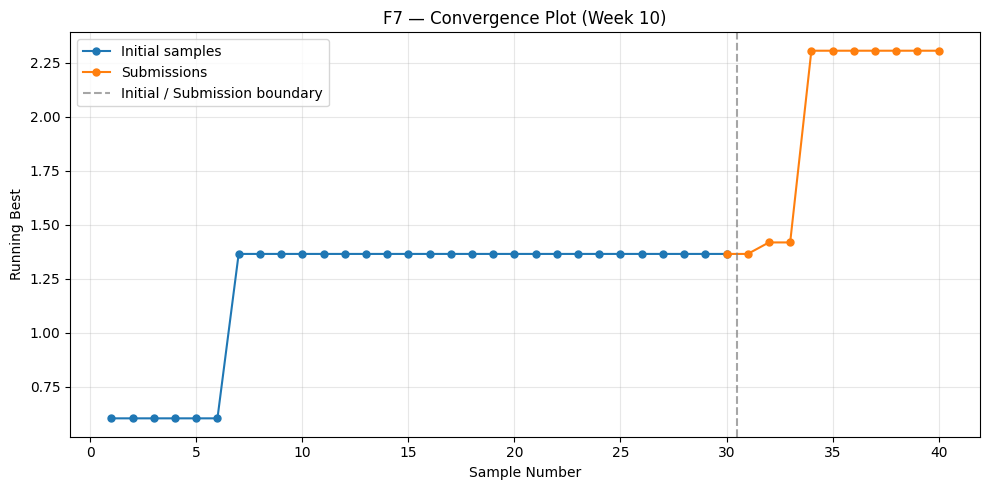

In [3]:
# Compute running best (maximisation)
running_best = np.maximum.accumulate(outputs)

fig, ax = plt.subplots(figsize=(10, 5))

# Split into initial and submission regions
x_all = np.arange(1, n_total + 1)

if USE_LOG_SCALE:
    # Clamp non-positive values to epsilon before log
    plot_vals = np.where(running_best > 0, running_best, 1e-300)
    ax.set_yscale('log')
    ax.set_ylabel('Running Best (log scale)')
else:
    plot_vals = running_best
    ax.set_ylabel('Running Best')

# Plot initial samples in blue
ax.plot(x_all[:N_INITIAL], plot_vals[:N_INITIAL], 'o-', color='tab:blue',
        label='Initial samples', markersize=5)

# Plot submissions in orange
ax.plot(x_all[N_INITIAL-1:], plot_vals[N_INITIAL-1:], 'o-', color='tab:orange',
        label='Submissions', markersize=5)

# Vertical separator
ax.axvline(x=N_INITIAL + 0.5, color='grey', linestyle='--', alpha=0.7,
           label='Initial / Submission boundary')

ax.set_xlabel('Sample Number')
ax.set_title(f'F{FUNC_NUM} — Convergence Plot (Week {WEEK})')
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## Step 3 — 2D Pair Plots

Scatter plots of each unique pair of input dimensions showing spatial coverage. Initial samples in **blue** (unmarked), submission samples in **orange** (numbered by submission week).

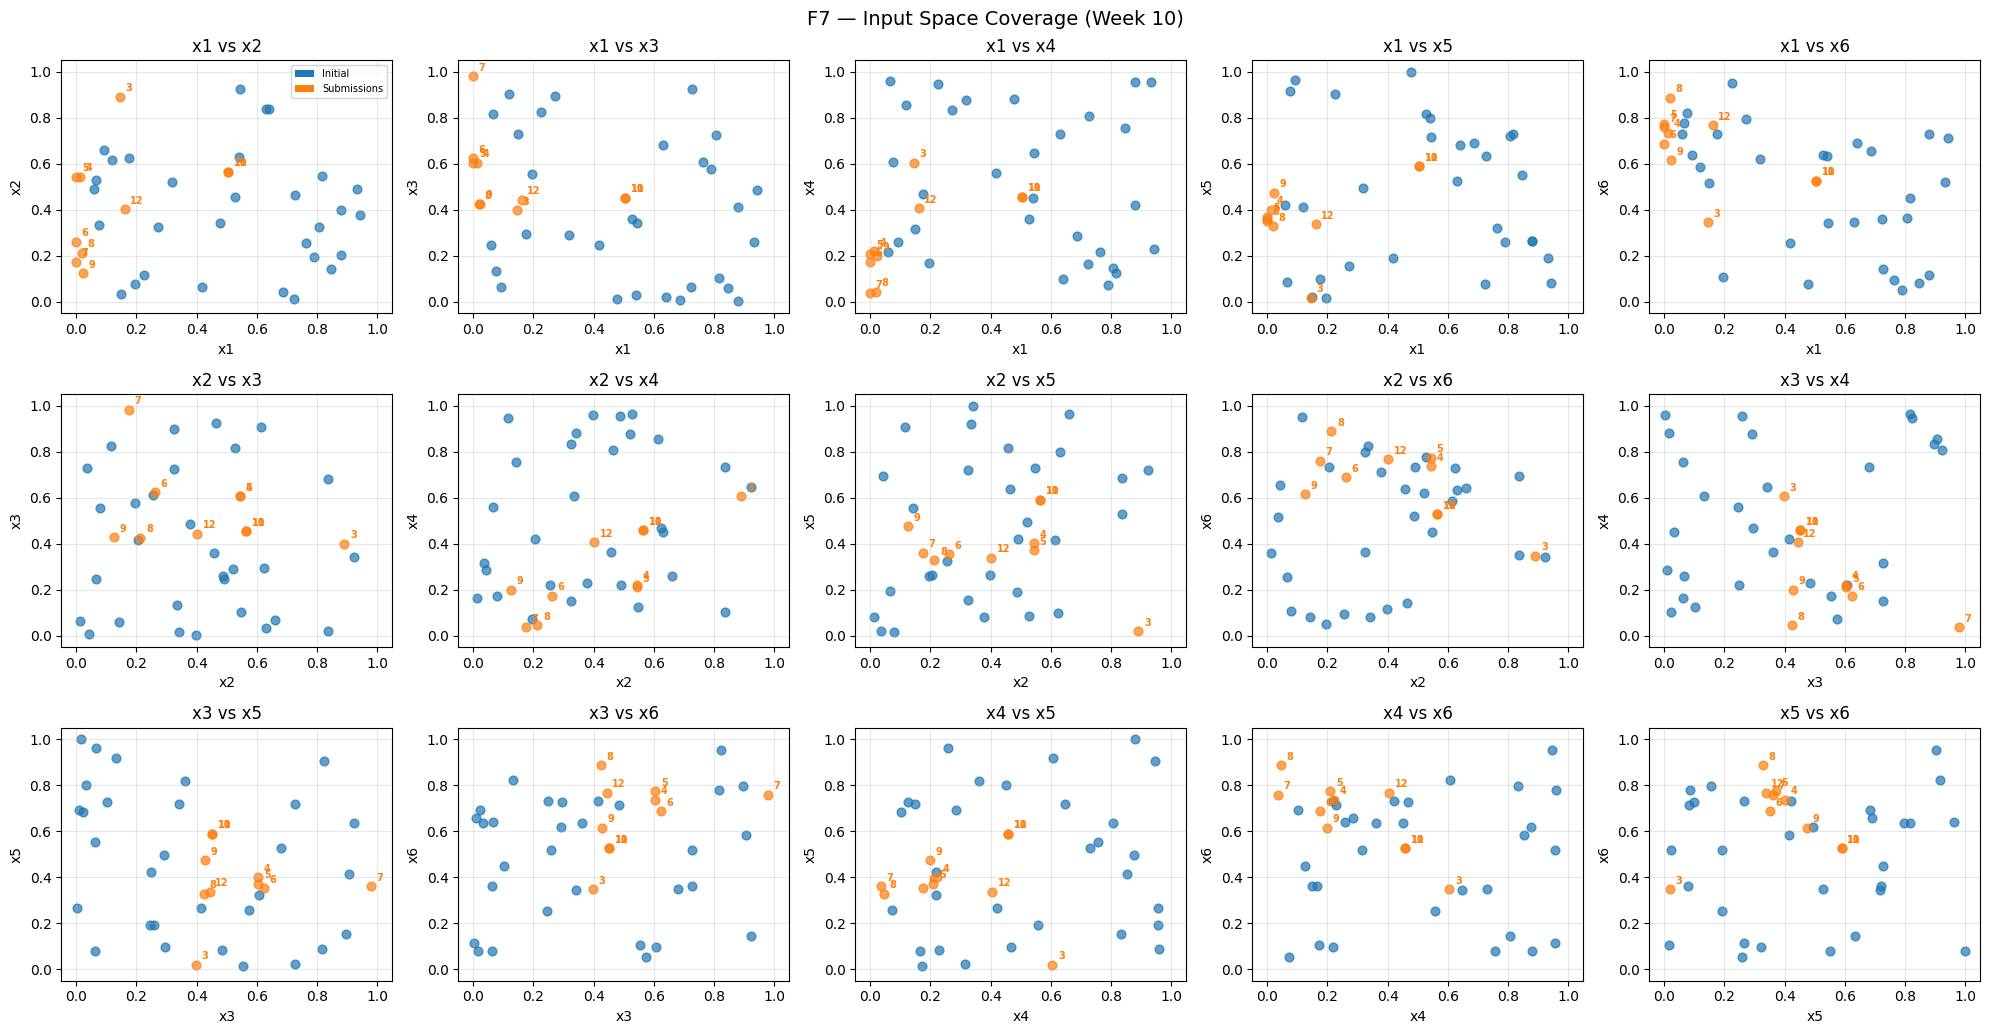

In [4]:
# Generate all unique pairs of input dimensions
pairs = list(combinations(range(N_DIMS), 2))
n_pairs = len(pairs)

if n_pairs == 0:
    print('Only 1 dimension — no pair plots to display.')
else:
    # Grid layout
    n_cols = min(n_pairs, 3) if n_pairs <= 6 else min(n_pairs, 5) if n_pairs <= 15 else 7
    n_rows = math.ceil(n_pairs / n_cols)
    fig_width = n_cols * 4
    fig_height = n_rows * 3.5

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(fig_width, fig_height),
                             squeeze=False)

    for idx, (di, dj) in enumerate(pairs):
        row, col = divmod(idx, n_cols)
        ax = axes[row][col]

        # Initial samples — blue, unmarked
        ax.scatter(inputs[:N_INITIAL, di], inputs[:N_INITIAL, dj],
                   c='tab:blue', marker='o', s=40, alpha=0.7, label='Initial')

        # Submission samples — orange, numbered by week
        for k in range(N_INITIAL, n_total):
            week_num = k - N_INITIAL + 3  # Weeks start at 3
            ax.scatter(inputs[k, di], inputs[k, dj],
                       c='tab:orange', marker='o', s=40, alpha=0.7)
            ax.annotate(str(week_num), (inputs[k, di], inputs[k, dj]),
                        textcoords='offset points', xytext=(4, 4),
                        fontsize=7, color='tab:orange', fontweight='bold')

        ax.set_xlabel(f'x{di+1}')
        ax.set_ylabel(f'x{dj+1}')
        ax.set_xlim(-0.05, 1.05)
        ax.set_ylim(-0.05, 1.05)
        ax.set_title(f'x{di+1} vs x{dj+1}')
        ax.grid(True, alpha=0.3)

    # Add legend to first subplot
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor='tab:blue', label='Initial'),
                       Patch(facecolor='tab:orange', label='Submissions')]
    axes[0][0].legend(handles=legend_elements, loc='upper right', fontsize=7)

    # Hide empty subplots
    for idx in range(n_pairs, n_rows * n_cols):
        row, col = divmod(idx, n_cols)
        axes[row][col].set_visible(False)

    fig.suptitle(f'F{FUNC_NUM} — Input Space Coverage (Week {WEEK})', fontsize=14)
    fig.tight_layout()
    plt.show()

## Step 4 — Performance Evaluation

### Current Strategy (Week 9)

- **Surrogate**: Neural Network (6→5→5→1, dropout=0.05)
- **Acquisition**: 70% mean + 30% EI blend, interior penalty
- **Key hyperparameters**: lr=0.005, 200 epochs, 20k candidates, STEEPNESS=0.05

### Performance Summary

In [5]:
# Performance metrics
running_best = np.maximum.accumulate(outputs)
init_best = running_best[N_INITIAL - 1]

# Count improvements and detect stalling
improvements = 0
consec_no_improve = 0
max_consec_no_improve = 0
prev_best = init_best

for j in range(N_INITIAL, n_total):
    if running_best[j] > prev_best:
        improvements += 1
        consec_no_improve = 0
    else:
        consec_no_improve += 1
        max_consec_no_improve = max(max_consec_no_improve, consec_no_improve)
    prev_best = running_best[j]

stalling = max_consec_no_improve >= 3

print(f'Best value (initial):     {init_best:.6g}')
print(f'Best value (final):       {running_best[-1]:.6g}')
print(f'Improvements:             {improvements}/{n_submissions}')
print(f'Max consecutive no-improve: {max_consec_no_improve}')
print(f'Stalling (≥3 consec):     {stalling}')
print()

# Per-submission performance
print('Week | Output         | Best-so-far    | Improved?')
print('-' * 55)
for j in range(N_INITIAL, n_total):
    week_num = j - N_INITIAL + 3
    improved = '✓' if (j == N_INITIAL and outputs[j] > init_best) or \
               (j > N_INITIAL and running_best[j] > running_best[j-1]) else '✗'
    print(f'  {week_num:>2d} | {outputs[j]:>14.6g} | {running_best[j]:>14.6g} | {improved}')

Best value (initial):     1.36497
Best value (final):       2.30499
Improvements:             2/10
Max consecutive no-improve: 6
Stalling (≥3 consec):     True

Week | Output         | Best-so-far    | Improved?
-------------------------------------------------------
   3 |       0.285444 |        1.36497 | ✗
   4 |        1.41816 |        1.41816 | ✓
   5 |        1.40491 |        1.41816 | ✗
   6 |        2.30499 |        2.30499 | ✓
   7 |       0.747724 |        2.30499 | ✗
   8 |        1.17215 |        2.30499 | ✗
   9 |        1.91349 |        2.30499 | ✗
  10 |       0.300001 |        2.30499 | ✗
  11 |       0.300001 |        2.30499 | ✗
  12 |        2.04327 |        2.30499 | ✗


### Evaluation

F7 has shown **limited progress** with **2 improvements** in 10 submission rounds. The best value moved from 1.365 (initial) to 2.305, but 6 consecutive non-improving submissions indicate the approach has plateaued.

Key observations:
- Only 2/10 submissions improved the running best — both early, followed by a long plateau
- 6 consecutive non-improving submissions is the second-worst stalling after F1 and F2
- The NN surrogate (6→5→5→1) is a non-standard choice that lacks the uncertainty quantification of GP-based models
- The 70% mean + 30% EI blend heavily favours exploitation, which compounds the lack of proper uncertainty
- Interior penalty is constraining the search space but the penalty parameters may be suboptimal
- 6D input space with 15 pair plots — high-dimensional exploration is challenging with only 10 additional samples

**Stalling status**: YES — 6 consecutive submissions without improvement.

## Step 5 — Proposed Strategy Improvements

F7 shows significant stalling (2/10 improvements, 6 consecutive non-improving). Major changes recommended:

1. **Consider switching from NN to GP-based surrogate** — The NN (6→5→5→1) lacks principled uncertainty quantification. The 30% EI component relies on a variance proxy that may not calibrate well. An SFGP with Matérn-2.5 ARD would provide proper posterior uncertainty for the acquisition function.

2. **If keeping NN: increase EI weight from 30% to 50%** — The current 70% mean + 30% EI blend is too exploitative. The mean component drives the search to the predicted best, which after 6 consecutive failures is clearly a local optimum.

3. **Review interior penalty parameters** — The STEEPNESS=0.05 may be too aggressive, excluding potentially interesting boundary regions. Consider reducing to 0.02 or using a softer penalty function.

4. **Increase candidate pool from 20k to 50k** — In 6D, 20k random candidates provide sparse coverage. More candidates increase the chance of finding promising unexplored regions.

5. **Add ensemble or dropout-based uncertainty** — If keeping the NN, use MC dropout (multiple forward passes with dropout=0.05 enabled) to generate uncertainty estimates rather than relying on the deterministic variance proxy.

**Priority**: HIGH — The NN surrogate approach has fundamentally stalled and needs either significant reconfiguration or replacement.

## Step 6 — Week 10 Optimisation Run

**Approach**: Keep NN surrogate (6→5→5→1, dropout=0.05) but shift acquisition toward balanced exploration by increasing EI weight and relaxing the interior penalty. Expand candidate pool for better 6D coverage.

| Change | Week 9 | Week 10 | Rationale |
|--------|--------|---------|-----------|
| EXPLOITATION_WEIGHT | 0.7 | **0.5** | 50/50 mean/EI blend — more exploration after 6 consecutive non-improving |
| STEEPNESS | 0.05 | **0.02** | Near-no-op penalty (sin^0.04 ≈ 1 everywhere except boundaries) |
| N_CANDIDATES | 20,000 | **50,000** | Better coverage in 6D space |
| MC_SAMPLES | 30 | **≥50** | More stable MC dropout uncertainty estimates |

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)

# ── Week 10 Constants ──
LEARNING_RATE       = 0.005
EPOCHS              = 200
DROPOUT             = 0.05
MC_SAMPLES          = 50       # Was 30 — more stable uncertainty
N_CANDIDATES        = 50_000   # Was 20,000 — better 6D coverage
STEEPNESS           = 0.02     # Was 0.05 — near-no-op penalty
FLOOR               = 0.02
EXPLOITATION_WEIGHT = 0.5      # Was 0.7 — balanced mean/EI blend
DIM                 = 6
GRID_RES            = 50

# ── Dataset constants ──
N_TOTAL        = len(outputs)  # from review cells
N_SUBMISSIONS  = N_TOTAL - N_INITIAL

hyperparam_names = ['learning_rate', 'reg_strength', 'n_layers', 'dropout', 'batch_size', 'optimizer']

print("Week 10 Constants:")
print(f"  DIM={DIM}, LEARNING_RATE={LEARNING_RATE}, EPOCHS={EPOCHS}, DROPOUT={DROPOUT}")
print(f"  MC_SAMPLES={MC_SAMPLES}, N_CANDIDATES={N_CANDIDATES:,}")
print(f"  STEEPNESS={STEEPNESS}, FLOOR={FLOOR}, EXPLOITATION_WEIGHT={EXPLOITATION_WEIGHT}")
print(f"  N_INITIAL={N_INITIAL}, N_TOTAL={N_TOTAL}, N_SUBMISSIONS={N_SUBMISSIONS}")

Week 10 Constants:
  DIM=6, LEARNING_RATE=0.005, EPOCHS=200, DROPOUT=0.05
  MC_SAMPLES=50, N_CANDIDATES=50,000
  STEEPNESS=0.02, FLOOR=0.02, EXPLOITATION_WEIGHT=0.5
  N_INITIAL=30, N_TOTAL=40, N_SUBMISSIONS=10


In [7]:
# ── Data Preparation & Z-Score Normalisation ──
X_raw = inputs   # from review cells — (N_TOTAL, 6)
y_raw = outputs  # from review cells — (N_TOTAL,)

assert X_raw.shape == (N_TOTAL, DIM), f"Expected ({N_TOTAL}, {DIM}), got {X_raw.shape}"
assert y_raw.shape == (N_TOTAL,), f"Expected ({N_TOTAL},), got {y_raw.shape}"
assert np.all((X_raw >= 0.0) & (X_raw <= 1.0)), "All inputs must be in [0, 1]"
assert np.all(y_raw > 0), "All F7 outputs should be positive"

# Split initial vs submissions
X_initial, y_initial = X_raw[:N_INITIAL], y_raw[:N_INITIAL]
X_submissions, y_submissions = X_raw[N_INITIAL:], y_raw[N_INITIAL:]

# Z-score normalisation
X_mean, X_std = X_raw.mean(axis=0), X_raw.std(axis=0) + 1e-8
y_mean, y_std = y_raw.mean(), y_raw.std() + 1e-8

X_norm = (X_raw - X_mean) / X_std
y_norm = (y_raw - y_mean) / y_std

# Torch tensors for NN training
X_tensor = torch.tensor(X_norm, dtype=torch.float32)
y_tensor = torch.tensor(y_norm, dtype=torch.float32).unsqueeze(1)

print(f"Week 10 Data: {X_raw.shape[0]} samples, {X_raw.shape[1]} dimensions")
print(f"  Initial: {N_INITIAL}, Submissions: {N_SUBMISSIONS}")
print(f"Output range: [{y_raw.min():.6f}, {y_raw.max():.6f}]")
print(f"Best observed: {y_raw.max():.6f} at sample {y_raw.argmax()}")
print(f"Normalisation: y_mean={y_mean:.6f}, y_std={y_std:.6f}")

Week 10 Data: 40 samples, 6 dimensions
  Initial: 30, Submissions: 10
Output range: [0.002701, 2.304991]
Best observed: 2.304991 at sample 33
Normalisation: y_mean=0.461958, y_std=0.611921


In [8]:
# ── Define & Train Neural Network (6→5→5→1) ──
class SurrogateNN(nn.Module):
    """Compact NN surrogate: 6→5→5→1 (71 parameters)."""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(6, 5),
            nn.ReLU(),
            nn.Dropout(p=DROPOUT),
            nn.Linear(5, 5),
            nn.ReLU(),
            nn.Dropout(p=DROPOUT),
            nn.Linear(5, 1)
        )

    def forward(self, x):
        return self.net(x)

torch.manual_seed(42)
model = SurrogateNN()
n_params = sum(p.numel() for p in model.parameters())
print(f"Architecture: 6→5→5→1, Parameters: {n_params}")

# Train with Adam, MSE loss
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion = nn.MSELoss()

losses = []
model.train()
for epoch in range(EPOCHS):
    optimizer.zero_grad()
    pred = model(X_tensor)
    loss = criterion(pred, y_tensor)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    if (epoch + 1) % 40 == 0:
        print(f"  Epoch {epoch+1}/{EPOCHS}, Loss: {loss.item():.6f}")

# Training R² on original scale
model.eval()
with torch.no_grad():
    train_pred = model(X_tensor).squeeze().numpy()
train_pred_orig = train_pred * y_std + y_mean
train_r2 = 1 - np.sum((y_raw - train_pred_orig)**2) / np.sum((y_raw - y_raw.mean())**2)
print(f"\nTraining R²: {train_r2:.6f}")
print(f"Final loss: {losses[-1]:.6f}")

Architecture: 6→5→5→1, Parameters: 71
  Epoch 40/200, Loss: 0.687006
  Epoch 80/200, Loss: 0.551286
  Epoch 120/200, Loss: 0.433334
  Epoch 160/200, Loss: 0.224039
  Epoch 200/200, Loss: 0.178752

Training R²: 0.857771
Final loss: 0.178752


In [9]:
# ── Balanced Acquisition: 50% Mean + 50% EI + Interior Penalty ──

# 1. Generate random candidates in [0,1]⁶
np.random.seed(42)
candidates = np.random.uniform(0, 1.0, size=(N_CANDIDATES, DIM))

# 2. Normalise candidates and run MC Dropout forward passes
cand_norm = (candidates - X_mean) / X_std
cand_tensor = torch.tensor(cand_norm, dtype=torch.float32)

model.train()  # enable dropout for MC sampling
mc_predictions = []
with torch.no_grad():
    for _ in range(MC_SAMPLES):
        pred = model(cand_tensor).squeeze().numpy()
        mc_predictions.append(pred)

# 3. Un-normalise predictions to original scale
mc_preds_orig = np.array(mc_predictions) * y_std + y_mean  # (MC_SAMPLES, N_CANDIDATES)
mu = mc_preds_orig.mean(axis=0)
sigma = mc_preds_orig.std(axis=0)

# 4. Compute EI via sample-then-average (non-parametric)
y_best = y_raw.max()
ei = np.mean(np.maximum(mc_preds_orig - y_best, 0), axis=0)

# 5. Normalise mean and EI for weighted blend
mu_norm = (mu - mu.min()) / (mu.max() - mu.min() + 1e-8)
ei_norm = ei / (ei.max() + 1e-8)

# 6. Combined acquisition: 50% mean + 50% EI (balanced blend)
combined_acq = EXPLOITATION_WEIGHT * mu_norm + (1 - EXPLOITATION_WEIGHT) * ei_norm

# 7. Interior penalty: w(x) = FLOOR + (1-FLOOR) · ∏ᵢ sin(πxᵢ)^(2·STEEPNESS)
interior_weight = FLOOR + (1 - FLOOR) * np.prod(
    np.sin(np.pi * candidates) ** (2 * STEEPNESS), axis=1
)

# 8. Penalised acquisition
penalised_acq = combined_acq * interior_weight

# 9. Select best candidate
raw_best_idx = np.argmax(combined_acq)
if penalised_acq.max() > 0:
    best_idx = np.argmax(penalised_acq)
else:
    best_idx = np.argmax(mu)
    print("⚠ All acquisition = 0 — fallback to highest predicted mean")

best_point = candidates[best_idx]

# 10. Duplicate check
dists_to_train = np.linalg.norm(X_raw - best_point, axis=1)
is_duplicate = dists_to_train.min() < 1e-4

# 11. Format submission
submission_point = np.clip(best_point, 0.0, 0.999999)
proposed_query = "-".join(f"{v:.6f}" for v in submission_point)

penalty_changed = (best_idx != raw_best_idx)
percentile_rank = np.mean(mu < mu[best_idx]) * 100

print("=== Balanced Acquisition (Week 10) ===")
print(f"  y_best (observed)    = {y_best:.6f}")
print(f"  EI range             = [{ei.min():.6f}, {ei.max():.6f}]")
print(f"  Penalty weight range = [{interior_weight.min():.4f}, {interior_weight.max():.4f}]")
print(f"  Blend: {EXPLOITATION_WEIGHT:.0%} mean + {1-EXPLOITATION_WEIGHT:.0%} EI")
print(f"  Penalty changed selection: {'YES' if penalty_changed else 'NO'}")
print(f"  Predicted mean (μ)   = {mu[best_idx]:.6f}")
print(f"  Predicted std (σ)    = {sigma[best_idx]:.6f}")
print(f"  Percentile rank      = {percentile_rank:.1f}th")
print(f"  Duplicate: {'YES ⚠' if is_duplicate else 'NO ✓'}")
print(f"\n>>> SUBMISSION: {proposed_query}")

=== Balanced Acquisition (Week 10) ===
  y_best (observed)    = 2.304991
  EI range             = [0.000000, 0.000000]
  Penalty weight range = [0.4611, 0.9972]
  Blend: 50% mean + 50% EI
  Penalty changed selection: YES
  Predicted mean (μ)   = 1.554791
  Predicted std (σ)    = 0.212860
  Percentile rank      = 99.9th
  Duplicate: NO ✓

>>> SUBMISSION: 0.045091-0.528666-0.329265-0.105350-0.434671-0.641164


Feature Importance (Input Gradient Magnitude):
  x0 ( learning_rate): 0.2495 █████████ ◄ top-2
  x1 (  reg_strength): 0.0519 ██
  x2 (      n_layers): 0.1683 ██████
  x3 (       dropout): 0.0909 ███
  x4 (    batch_size): 0.2357 █████████ ◄ top-2
  x5 (     optimizer): 0.2037 ████████


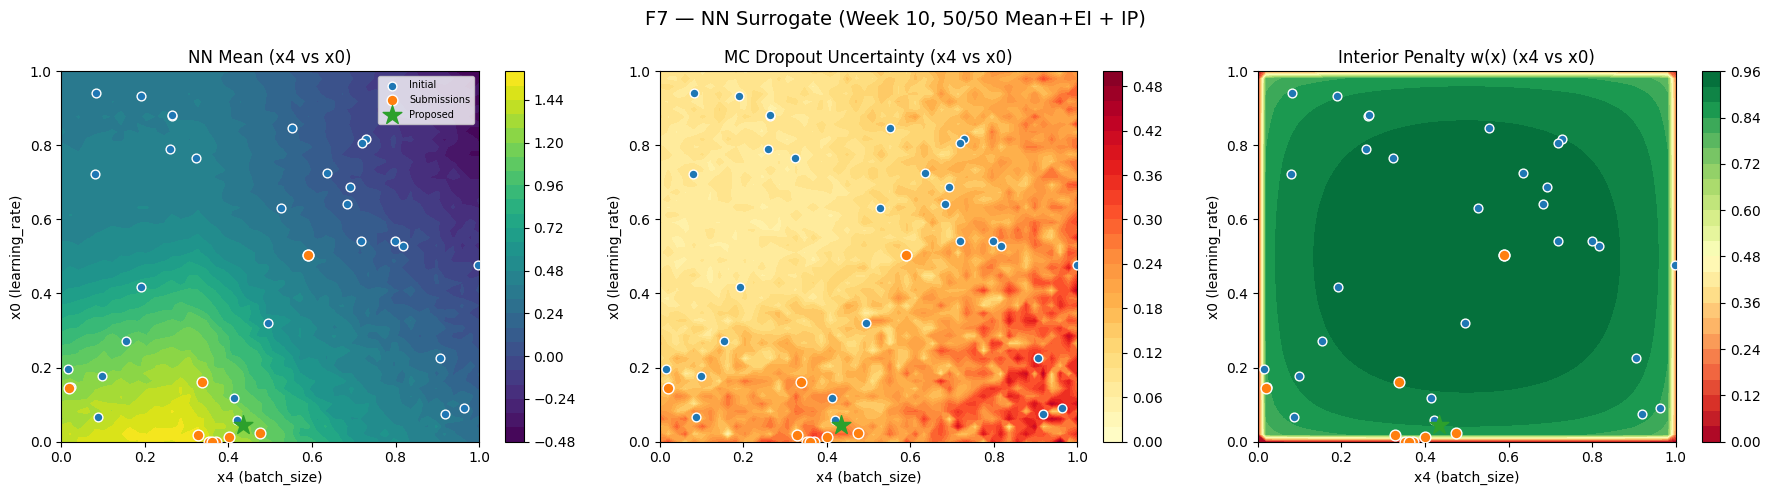

In [10]:
# ── Feature Importance & 3-Panel Visualisation ──

# Feature importance via input gradients
model.eval()
X_grad = torch.tensor(X_norm, dtype=torch.float32, requires_grad=True)
output = model(X_grad).sum()
output.backward()

grad_importance = X_grad.grad.abs().mean(dim=0).numpy()
grad_importance = grad_importance / grad_importance.sum()
top2 = np.argsort(grad_importance)[-2:]

print("Feature Importance (Input Gradient Magnitude):")
for i, imp in enumerate(grad_importance):
    bar = '█' * int(imp * 40)
    marker = ' ◄ top-2' if i in top2 else ''
    print(f"  x{i} ({hyperparam_names[i]:>14s}): {imp:.4f} {bar}{marker}")

# Build grid on top-2 dimensions
fixed_dims = [d for d in range(DIM) if d not in top2]
best_obs = X_raw[y_raw.argmax()]

g0 = np.linspace(0, 1, GRID_RES)
g1 = np.linspace(0, 1, GRID_RES)
G0, G1 = np.meshgrid(g0, g1)

grid_pts = np.zeros((GRID_RES * GRID_RES, DIM))
grid_pts[:, top2[0]] = G0.ravel()
grid_pts[:, top2[1]] = G1.ravel()
for d in fixed_dims:
    grid_pts[:, d] = best_obs[d]

# MC Dropout predictions on grid
grid_norm = (grid_pts - X_mean) / X_std
grid_tensor = torch.tensor(grid_norm, dtype=torch.float32)

model.train()
grid_mc = []
with torch.no_grad():
    for _ in range(MC_SAMPLES):
        p = model(grid_tensor).squeeze().numpy()
        grid_mc.append(p)
grid_mc = np.array(grid_mc) * y_std + y_mean

grid_mu = grid_mc.mean(axis=0).reshape(GRID_RES, GRID_RES)
grid_sigma = grid_mc.std(axis=0).reshape(GRID_RES, GRID_RES)

# Interior penalty on grid
grid_penalty = FLOOR + (1 - FLOOR) * np.prod(
    np.sin(np.pi * grid_pts) ** (2 * STEEPNESS), axis=1
).reshape(GRID_RES, GRID_RES)

# Plot 3 panels
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax in axes:
    ax.scatter(X_initial[:, top2[0]], X_initial[:, top2[1]],
               c='tab:blue', edgecolors='white', s=40, zorder=5, label='Initial')
    ax.scatter(X_submissions[:, top2[0]], X_submissions[:, top2[1]],
               c='tab:orange', edgecolors='white', s=60, zorder=5, label='Submissions')
    ax.scatter(best_point[top2[0]], best_point[top2[1]],
               c='tab:green', marker='*', s=200, zorder=6, label='Proposed')

c1 = axes[0].contourf(G0, G1, grid_mu, levels=30, cmap='viridis')
axes[0].set_title(f"NN Mean (x{top2[0]} vs x{top2[1]})")
axes[0].set_xlabel(f"x{top2[0]} ({hyperparam_names[top2[0]]})")
axes[0].set_ylabel(f"x{top2[1]} ({hyperparam_names[top2[1]]})")
fig.colorbar(c1, ax=axes[0])

c2 = axes[1].contourf(G0, G1, grid_sigma, levels=30, cmap='YlOrRd')
axes[1].set_title(f"MC Dropout Uncertainty (x{top2[0]} vs x{top2[1]})")
axes[1].set_xlabel(f"x{top2[0]} ({hyperparam_names[top2[0]]})")
axes[1].set_ylabel(f"x{top2[1]} ({hyperparam_names[top2[1]]})")
fig.colorbar(c2, ax=axes[1])

c3 = axes[2].contourf(G0, G1, grid_penalty, levels=30, cmap='RdYlGn')
axes[2].set_title(f"Interior Penalty w(x) (x{top2[0]} vs x{top2[1]})")
axes[2].set_xlabel(f"x{top2[0]} ({hyperparam_names[top2[0]]})")
axes[2].set_ylabel(f"x{top2[1]} ({hyperparam_names[top2[1]]})")
fig.colorbar(c3, ax=axes[2])

axes[0].legend(loc='upper right', fontsize=7)
plt.suptitle("F7 — NN Surrogate (Week 10, 50/50 Mean+EI + IP)", fontsize=14)
plt.tight_layout()
plt.show()

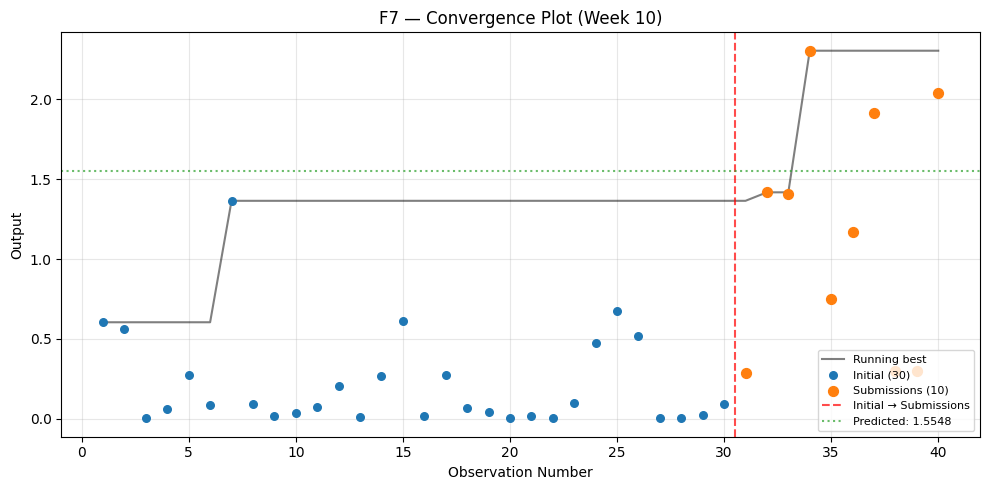

Running best at Week 10 end: 2.304991
Predicted value for proposed point: 1.5548

=== Final Validation ===
✓ Format: 6 dimensions
✓ Range: all in [0, 0.999999]
✓ Duplicate: NO

>>> FINAL SUBMISSION: 0.045091-0.528666-0.329265-0.105350-0.434671-0.641164


In [11]:
# ── Convergence Plot ──
running_best_all = np.maximum.accumulate(y_raw)
indices = np.arange(1, len(y_raw) + 1)

plt.figure(figsize=(10, 5))
plt.plot(indices, running_best_all, 'k-', linewidth=1.5, alpha=0.5, label='Running best')

plt.scatter(indices[:N_INITIAL], y_raw[:N_INITIAL],
            c='tab:blue', s=30, zorder=4, label=f'Initial ({N_INITIAL})')
plt.scatter(indices[N_INITIAL:], y_raw[N_INITIAL:],
            c='tab:orange', s=50, zorder=4, label=f'Submissions ({N_SUBMISSIONS})')

plt.axvline(x=N_INITIAL + 0.5, color='red', linestyle='--', alpha=0.7,
            label='Initial → Submissions')
plt.axhline(y=mu[best_idx], color='tab:green', linestyle=':', alpha=0.7,
            label=f'Predicted: {mu[best_idx]:.4f}')

plt.xlabel("Observation Number")
plt.ylabel("Output")
plt.title("F7 — Convergence Plot (Week 10)")
plt.legend(loc='lower right', fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Running best at Week 10 end: {running_best_all[-1]:.6f}")
print(f"Predicted value for proposed point: {mu[best_idx]:.4f}")

# Final validation
parts = proposed_query.split("-")
print(f"\n=== Final Validation ===")
print(f"✓ Format: {len(parts)} dimensions")
all_valid = all(0.0 <= float(p) <= 0.999999 for p in parts)
print(f"{'✓' if all_valid else '✗'} Range: all in [0, 0.999999]")
print(f"{'✓' if not is_duplicate else '✗'} Duplicate: {'YES ⚠' if is_duplicate else 'NO'}")
print(f"\n>>> FINAL SUBMISSION: {proposed_query}")